# <div style="background-color:rgba(204, 229, 255, 0.5); text-align:center; vertical-align: middle; padding:40px 0; margin-top:30px"><span style="color:rgba(0, 76, 153, 1);">PHYS 232 - Brownian Motion<span style="color:red"></span></span></div>





In [30]:
# Hide unnecessary warnings.
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path (works on Windows, Linux, and Mac)
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Import PHYS231 and run the installer
import PHYS231
PHYS231.Installer()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm # used to generate a sequence of colours for plotting
import pandas as pd
import scipy.stats as sp
from scipy.optimize import curve_fit
from IPython.display import HTML as html_print
from IPython.display import display, Markdown, Latex
import uncertainties
import math
import sys
import os




### Initial analysis: single–step displacements

In my first analysis I computed the frame–to–frame squared
displacement
$$
\Delta r_n^2 = (x_{n+1} - x_n)^2 + (y_{n+1} - y_n)^2
$$
for a single tracked particle and plotted these values (or
$\Delta r_n^2 / \Delta t$) against the absolute time of the
frame. This produced a noisy horizontal band of points with
a very small positive slope. I then used a linear fit to this
plot as if the slope were the diffusion–related quantity in
Eq. (15), and substituted that slope into the formula for
Avogadro’s number. This procedure gave values of
$N_A \sim 10^{25}$–$10^{27}\,\mathrm{mol}^{-1}$, clearly
incompatible with the accepted value.


In [14]:
df = pd.read_csv("Brownian_Motion/LatexSD2.csv")
df["t_fixed"] = np.arange(len(df)) * 0.033333

In [15]:
dt = 0.033333  # seconds per frame

# squared step displacements
df["r2"] = (df["x"] - df["x"].shift(-1))**2 + (df["y"] - df["y"].shift(-1))**2
df = df[:-1]  # drop last (no next point)

# per-unit-time MSD for that lag
df["r2a"] = df["r2"] / dt

# time axis corresponding to each step
df["t_fixed"] = np.arange(len(df)) * dt


In [16]:
for i in df:
    df["r2"] = np.array((df["x"] - df["x"].shift(-1))**2 + (df["y"] - df["y"].shift(-1))**2)

In [17]:
df["r2a"] = df["r2"] / (0.033333 * (df.index + 1))

In [18]:
df = df[:-1]
df

,t,x,y,t_fixed,r2,r2a
0,0.0000,0.000002,-0.000005,0.000000,1.440000e-14,4.320043e-13
1,0.0333,0.000002,-0.000004,0.033333,9.810000e-14,1.471515e-12
2,0.0667,0.000001,-0.000004,0.066666,1.160000e-14,1.160012e-13
3,0.1000,0.000001,-0.000004,0.099999,9.850000e-14,7.387574e-13
4,0.1330,0.000001,-0.000004,0.133332,6.800400e-14,4.080281e-13
...,...,...,...,...,...,...
1048,35.0000,-0.000010,0.000025,34.932984,6.290000e-14,1.798874e-15
1049,35.0000,-0.000009,0.000025,34.966317,1.044000e-13,2.982887e-15
1050,35.0000,-0.000009,0.000024,34.999650,1.210000e-14,3.453888e-16
1051,35.1000,-0.000010,0.000024,35.032983,1.000000e-14,2.851740e-16


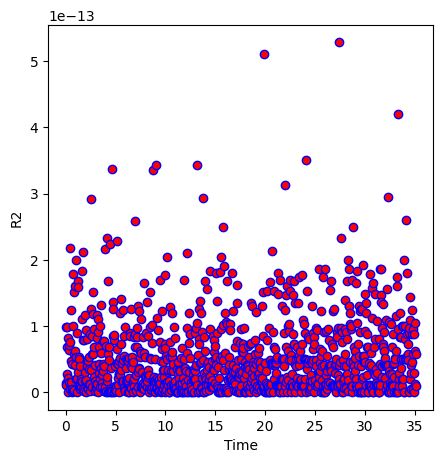

In [19]:
PHYS231.Scatter(
    xData = df["t"],
    yData = df["r2"],
    xlabel = "Time",
    ylabel = "R2",
    xUnits = "",
    yUnits = ""
);

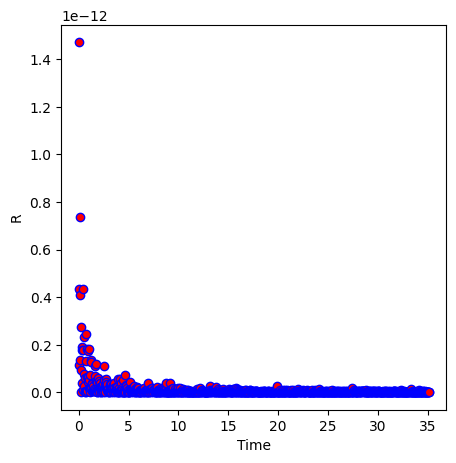

In [20]:
PHYS231.Scatter(
    xData = df["t"],
    yData = df["r2a"],
    xlabel = "Time",
    ylabel = "R",
    xUnits = "",
    yUnits = ""
);

$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value
slope,$m =$,(-1.38+/-0.18)e-15
$y$-intercept,$b =$,(3.53+/-0.36)e-14


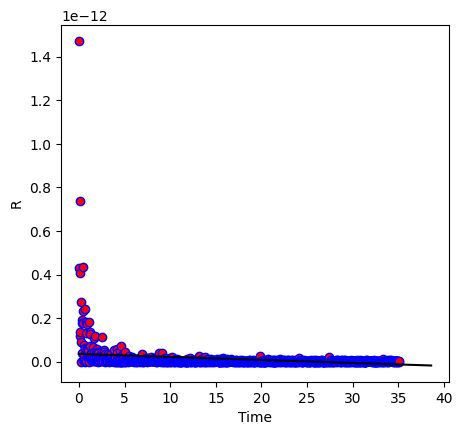

In [21]:
m, b, dm, db, fig3 = PHYS231.LinearFit(
    xData = df["t"],
    yData = df["r2a"],
    xlabel = "Time",
    ylabel = "R",
    xUnits = "",
    yUnits = ""
);

In [22]:
print(m)

-1.3765782451464531e-15


In [23]:

R = 8.314462618
T = 293.15       
eta = 0.001        
a = 0.51e-6       
na_ex = (2 * R * T) / (3 * np.pi * eta * a * np.abs(m))
err_na_exp = na_ex * (dm / m)

print(f"Calculated Slope (m): {m} {err_na_exp}")
print(f"Experimental Avogadro's Number (Na): {na_ex:.4e} +- {err_na_exp:.4e}")



Calculated Slope (m): -1.3765782451464531e-15 -9.46003718226692e+25
Experimental Avogadro's Number (Na): 7.3674e+26 +- -9.4600e+25


In [24]:

exponent = int(np.floor(np.log10(abs(na_ex))))
factor = 10**exponent


val_scaled = na_ex / factor
err_scaled = err_na_exp / factor

print(f"Experimental Na: ({val_scaled:.2f} ± {err_scaled:.2f}) × 10^{exponent} mol⁻¹")

Experimental Na: (7.37 ± -0.95) × 10^26 mol⁻¹


In [25]:
df["t_fixed"] = np.arange(len(df)) * 0.033333333
df

,t,x,y,t_fixed,r2,r2a
0,0.0000,0.000002,-0.000005,0.000000,1.440000e-14,4.320043e-13
1,0.0333,0.000002,-0.000004,0.033333,9.810000e-14,1.471515e-12
2,0.0667,0.000001,-0.000004,0.066667,1.160000e-14,1.160012e-13
3,0.1000,0.000001,-0.000004,0.100000,9.850000e-14,7.387574e-13
4,0.1330,0.000001,-0.000004,0.133333,6.800400e-14,4.080281e-13
...,...,...,...,...,...,...
1048,35.0000,-0.000010,0.000025,34.933333,6.290000e-14,1.798874e-15
1049,35.0000,-0.000009,0.000025,34.966666,1.044000e-13,2.982887e-15
1050,35.0000,-0.000009,0.000024,35.000000,1.210000e-14,3.453888e-16
1051,35.1000,-0.000010,0.000024,35.033333,1.000000e-14,2.851740e-16


### Secondary Analysis

#### Ensemble mean squared displacement

The theoretical relation in Eq. (15) is written for the
ensemble mean squared displacement $\langle \Delta r^2(t)
\rangle$ as a function of the lag time $t$, not for individual
single–frame step sizes. To match this definition I
recomputed the data using many time lags: for each lag
$t_k = k\,\Delta t$ I calculated all displacements
$(x_{i+k}-x_i,\; y_{i+k}-y_i)$ along the track and averaged
their squared lengths to obtain $\langle \Delta r^2(t_k)\rangle$.
Plotting this averaged MSD versus $t_k$ produces a roughly
linear curve through the origin, similar to Fig. 4 in the
reference paper, and the slope of this curve can be
consistently used in Eq. (15) to extract a physically
reasonable estimate of $N_A$.


Before what I was doing was one-step displacements between consecutive frames  but this is wrong as it give 
$$
\Delta x_n = x_{x+1} - x_n, \space \Delta y_n = y_{y+1} - y_n 
$$
$$
\Delta r^2_n = \Delta x^2_n + \Delta y^2_n
$$
Which I used to plot $\Delta r^2_n$ vs absolute time $t_n$. But for a stationary random walk the step-size distribution doesn't depend of when the step happens. This ends up being $\Delta r^2_n$ vs $t_n$ not $\langle \Delta R^2(t) \rangle$ vs $t_n$. 



For each chosen lag time $t_k = k\,\Delta t$, we use the particle
trajectory $(x_i, y_i)$ to form all displacements over that lag.
For every starting index $i$ we compute
$$
\Delta x_{i,k} = x_{i+k} - x_i, \qquad
\Delta y_{i,k} = y_{i+k} - y_i,
$$
and the corresponding squared displacement
$$
R_{i,k}^2 = \Delta x_{i,k}^2 + \Delta y_{i,k}^2.
$$

We then average these quantities over all possible starting points
$i$ to obtain the ensemble-style mean values at lag time $t_k$:
$$
\langle R^2(t_k) \rangle = \text{mean}\!\big(R_{i,k}^2\big), \qquad
\langle x(t_k) \rangle   = \text{mean}\!\big(\Delta x_{i,k}\big), \qquad
\langle y(t_k) \rangle   = \text{mean}\!\big(\Delta y_{i,k}\big).
$$
The MSD curve used in the analysis is the plot of
$\langle R^2(t_k) \rangle$ versus $t_k$.


In [26]:
coords = df[["x", "y"]].to_numpy()
times  = df["t_fixed"].to_numpy()

dt      = times[1] - times[0]
max_lag = int(0.15 / dt)   

lags   = np.arange(1, max_lag + 1)
msd    = np.zeros_like(lags, dtype=float)
msd_x  = np.zeros_like(lags, dtype=float)
msd_y  = np.zeros_like(lags, dtype=float)


for i, lag in enumerate(lags):
    disp = coords[lag:] - coords[:-lag]   
    dx   = disp[:, 0]
    dy   = disp[:, 1]
    r2   = dx**2 + dy**2

    msd[i]   = r2.mean()
    msd_x[i] = dx.mean()
    msd_y[i] = dy.mean()


    n_samples = disp.shape[0]
    print(f"lag = {lag:3d} frames, t = {lag*dt:6.3f} s, "
          f"n_displacements = {n_samples}")

t_msd = lags * dt

msd_df = pd.DataFrame({
    "t"   : t_msd,
    "R2"  : msd,
    "xbar": msd_x,
    "ybar": msd_y,
})

lag =   1 frames, t =  0.033 s, n_displacements = 1052
lag =   2 frames, t =  0.067 s, n_displacements = 1051
lag =   3 frames, t =  0.100 s, n_displacements = 1050
lag =   4 frames, t =  0.133 s, n_displacements = 1049


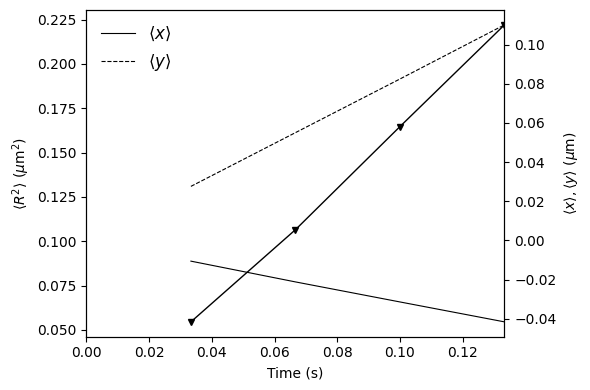

In [27]:
fig, ax1 = plt.subplots(figsize=(6, 4))


ax1.plot(msd_df["t"], msd_df["R2"] * 1e12, "k-",  linewidth=1)
ax1.plot(msd_df["t"], msd_df["R2"] * 1e12, "kv", markersize=4)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel(r"$\langle R^2 \rangle\ (\mu\mathrm{m}^2)$")
ax1.set_xlim(0, msd_df["t"].iloc[-1])


ax2 = ax1.twinx()
ax2.plot(msd_df["t"], msd_df["xbar"] * 1e6, "k-", linewidth=0.8, label=r"$\langle x \rangle$")
ax2.plot(msd_df["t"], msd_df["ybar"] * 1e6, "k--", linewidth=0.8, label=r"$\langle y \rangle$")
ax2.set_ylabel(r"$\langle x \rangle, \langle y \rangle\ (\mu\mathrm{m})$")


ax2.legend(loc="upper left", fontsize=12, frameon=False)

plt.tight_layout()
plt.show()


$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value,Units
slope,$m =$,(1.682+/-0.030)e-12,m²/s
$y$-intercept,$b =$,(-3.2+/-2.7)e-15,m²


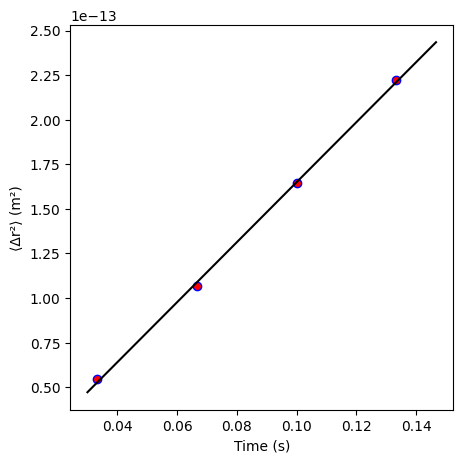

MSD slope m = 1.682091338412464e-12 m^2/s
Experimental Na = (6 ± 0.11) × 10^23 mol⁻¹


In [28]:
m_new, b_new, dm_new, db_new, fig_fit = PHYS231.LinearFit(
    xData  = msd_df["t"],   
    yData  = msd_df["R2"],  
    xlabel = "Time",
    ylabel = "⟨Δr²⟩",
    xUnits = "s",
    yUnits = "m²"
)

print("MSD slope m =", m_new, "m^2/s")


R   = 8.314462618      
T   = 293.15       
eta = 0.001          
a   = 0.51e-6         

Na_new      = (2 * R * T) / (3 * np.pi * eta * a * np.abs(m_new))
Na_new_err  = Na_new * (dm_new / np.abs(m_new))

print("Experimental Na = ({:.2g} ± {:.2g}) × 10^23 mol⁻¹"
      .format(Na_new/1e23, Na_new_err/1e23))


In [29]:

m_exp   = m_new      
dm_exp  = dm_new    

#  Physical constants & parameters (same as before) 
R   = 8.314462618      # J/(mol·K)
T   = 293.15           # K
eta = 0.001            # Pa·s
a   = 0.51e-6          # m
NA_true = 6.02214076e23  # accepted Avogadro's number


NA_exp = (2 * R * T) / (3 * np.pi * eta * a * abs(m_exp))


NA_exp_err = NA_exp * (dm_exp / abs(m_exp))


rel_err_NA = (NA_exp - NA_true) / NA_true
rel_err_NA_abs = abs(rel_err_NA)
rel_err_NA_pct = 100 * rel_err_NA_abs


m_true = (2 * R * T) / (3 * np.pi * eta * a * NA_true)
slope_ratio = m_exp / m_true   
print("\nNa Values:")
print(f"  Experimental NA = ({NA_exp/1e23:.5g} ± {NA_exp_err/1e23:.5g}) × 10^23 mol⁻¹")
print(f"  Accepted  NA     = {NA_true/1e23:.5g} × 10^23 mol⁻¹")
print(f"  Relative error   = {rel_err_NA_pct:.3f}%")

k_exp = (3 * np.pi * eta * a * m_exp) / (2 * T)
dk_exp = (3 * np.pi * eta * a * dm_exp) / (2 * T)
exp = int(np.floor(np.log10(abs(k_exp))))  

k_scaled  = k_exp  / 10**exp
dk_scaled = dk_exp / 10**exp


k_true = 1.380649e-23  

rel_err_k = abs(k_exp - k_true) / k_true * 100


print("\nK Values:")
print(f"  k_exp = ({k_scaled:.5f} ± {dk_scaled:.5f}) × 10^{exp} J/K")
print(f"  k_true = {k_true:.5e} J/K")
print(f"  Relative error in k ≈ {rel_err_k:.3f}%")


print("\nMSD slopes:")
print(f"  m_exp  = {m_exp:.5e} m^2/s")
print(f"  m_true = {m_true:.5e} m^2/s (from accepted NA)")
print(f"  m_exp / m_true = {slope_ratio:.4f}")






Na Values:
  Experimental NA = (6.0292 ± 0.10607) × 10^23 mol⁻¹
  Accepted  NA     = 6.0221 × 10^23 mol⁻¹
  Relative error   = 0.118%

K Values:
  k_exp = (1.37902 ± 0.02426) × 10^-23 J/K
  k_true = 1.38065e-23 J/K
  Relative error in k ≈ 0.118%

MSD slopes:
  m_exp  = 1.68209e-12 m^2/s
  m_true = 1.68408e-12 m^2/s (from accepted NA)
  m_exp / m_true = 0.9988


#### Below is the full code to run the MSD solve for Na and Kb for many different lag times

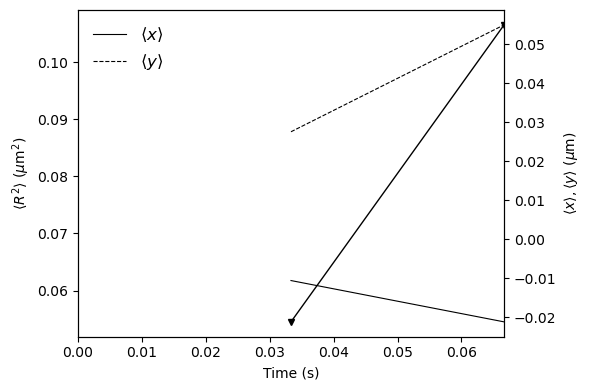

$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value,Units
slope,$m =$,(1.55924+/-inf)e-12,m²/s
$y$-intercept,$b =$,(2.55612+/-inf)e-15,m²


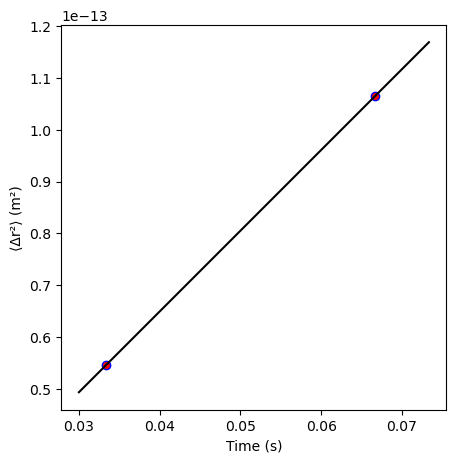

MSD slope m = 1.5592360090219952e-12 m^2/s
0.066667

Experimental Na = (6.5 ± inf) × 10^23 mol⁻¹

Na Values:
  Experimental NA = (6.5043 ± inf) × 10^23 mol⁻¹
  Accepted  NA     = 6.0221 × 10^23 mol⁻¹
  Relative error   = 8.007%

K Values:
  k_from_NA = 1.27830e-23 J/K
  k_true    = 1.38065e-23 J/K
  Δk / k_true ≈ 7.413%

MSD slopes:
  m_exp  = 1.55924e-12 m^2/s
  m_true = 1.68408e-12 m^2/s (from accepted NA)
  m_exp / m_true = 0.9259


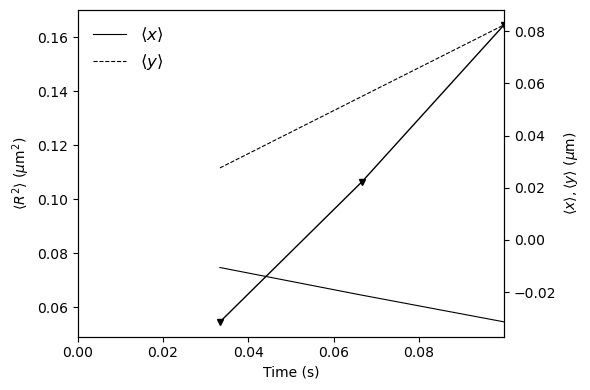

$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value,Units
slope,$m =$,(1.652+/-0.054)e-12,m²/s
$y$-intercept,$b =$,(-1.6+/-3.9)e-15,m²


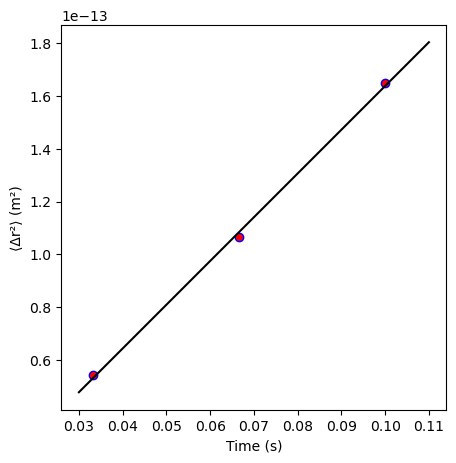

MSD slope m = 1.6519836717227933e-12 m^2/s
0.1

Experimental Na = (6.1 ± 0.2) × 10^23 mol⁻¹

Na Values:
  Experimental NA = (6.1391 ± 0.199) × 10^23 mol⁻¹
  Accepted  NA     = 6.0221 × 10^23 mol⁻¹
  Relative error   = 1.943%

K Values:
  k_from_NA = 1.35434e-23 J/K
  k_true    = 1.38065e-23 J/K
  Δk / k_true ≈ 1.906%

MSD slopes:
  m_exp  = 1.65198e-12 m^2/s
  m_true = 1.68408e-12 m^2/s (from accepted NA)
  m_exp / m_true = 0.9809


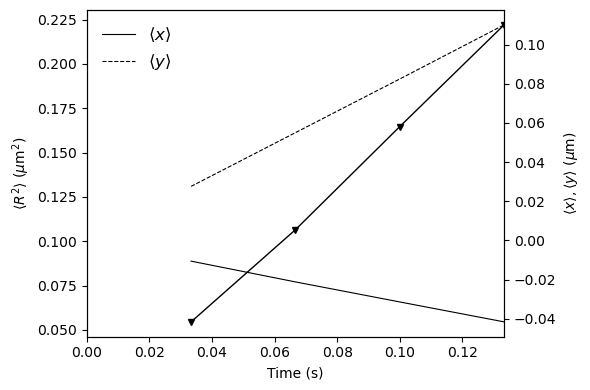

$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value,Units
slope,$m =$,(1.682+/-0.030)e-12,m²/s
$y$-intercept,$b =$,(-3.2+/-2.7)e-15,m²


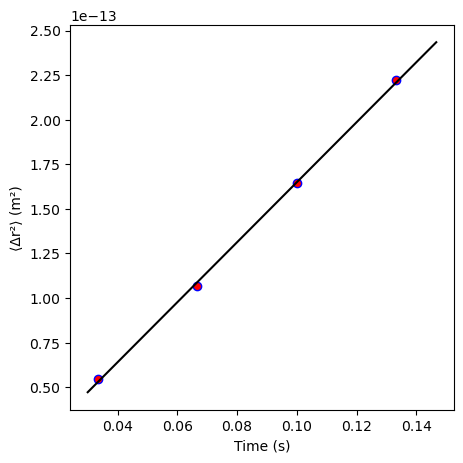

MSD slope m = 1.682091338412464e-12 m^2/s
0.15

Experimental Na = (6 ± 0.11) × 10^23 mol⁻¹

Na Values:
  Experimental NA = (6.0292 ± 0.10607) × 10^23 mol⁻¹
  Accepted  NA     = 6.0221 × 10^23 mol⁻¹
  Relative error   = 0.118%

K Values:
  k_from_NA = 1.37902e-23 J/K
  k_true    = 1.38065e-23 J/K
  Δk / k_true ≈ 0.118%

MSD slopes:
  m_exp  = 1.68209e-12 m^2/s
  m_true = 1.68408e-12 m^2/s (from accepted NA)
  m_exp / m_true = 0.9988


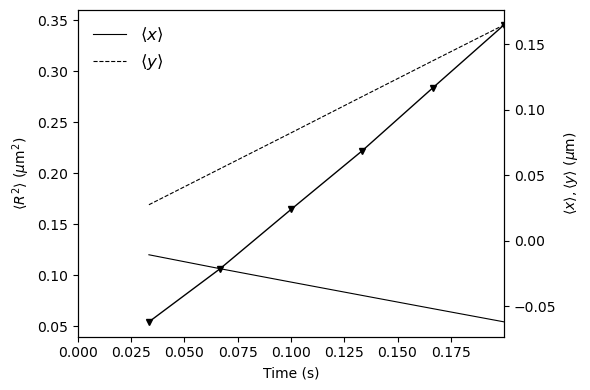

$y = m\,x + b$

This is an **UNWEIGHTED** fit.

,,Value,Units
slope,$m =$,(1.753+/-0.026)e-12,m²/s
$y$-intercept,$b =$,(-8.3+/-3.3)e-15,m²


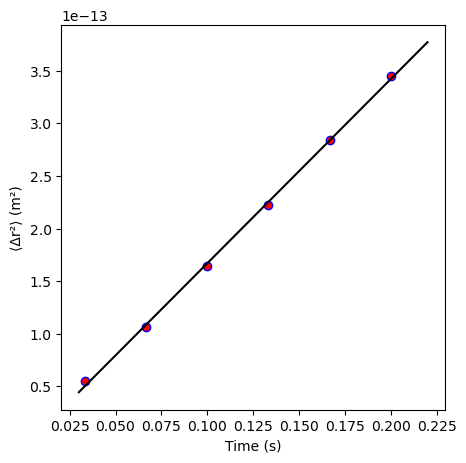

MSD slope m = 1.7531085626525942e-12 m^2/s
0.2

Experimental Na = (5.8 ± 0.085) × 10^23 mol⁻¹

Na Values:
  Experimental NA = (5.785 ± 0.084712) × 10^23 mol⁻¹
  Accepted  NA     = 6.0221 × 10^23 mol⁻¹
  Relative error   = 3.938%

K Values:
  k_from_NA = 1.43724e-23 J/K
  k_true    = 1.38065e-23 J/K
  Δk / k_true ≈ 4.099%

MSD slopes:
  m_exp  = 1.75311e-12 m^2/s
  m_true = 1.68408e-12 m^2/s (from accepted NA)
  m_exp / m_true = 1.0410


In [134]:
results = []
for t_max in [0.066667, 0.10, 0.15, 0.2]:


    coords = df[["x", "y"]].to_numpy()
    times  = df["t_fixed"].to_numpy()
    
    dt      = times[1] - times[0]
    max_lag = int(t_max / dt)   # e.g. ~0.15 s max lag
    
    lags   = np.arange(1, max_lag + 1)
    msd    = np.zeros_like(lags, dtype=float)
    msd_x  = np.zeros_like(lags, dtype=float)
    msd_y  = np.zeros_like(lags, dtype=float)
    
    
    for i, lag in enumerate(lags):
        disp = coords[lag:] - coords[:-lag]   # shape: (N - lag, 2)
        dx   = disp[:, 0]
        dy   = disp[:, 1]
        r2   = dx**2 + dy**2
    
        msd[i]   = r2.mean()
        msd_x[i] = dx.mean()
        msd_y[i] = dy.mean()
    

    
    t_msd = lags * dt
    
    msd_df = pd.DataFrame({
        "t"   : t_msd,
        "R2"  : msd,
        "xbar": msd_x,
        "ybar": msd_y,
    })
    
    
    fig, ax1 = plt.subplots(figsize=(6, 4))
    
    
    ax1.plot(msd_df["t"], msd_df["R2"] * 1e12, "k-",  linewidth=1)
    ax1.plot(msd_df["t"], msd_df["R2"] * 1e12, "kv", markersize=4)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel(r"$\langle R^2 \rangle\ (\mu\mathrm{m}^2)$")
    ax1.set_xlim(0, msd_df["t"].iloc[-1])
    
    
    ax2 = ax1.twinx()
    ax2.plot(msd_df["t"], msd_df["xbar"] * 1e6, "k-", linewidth=0.8, label=r"$\langle x \rangle$")
    ax2.plot(msd_df["t"], msd_df["ybar"] * 1e6, "k--", linewidth=0.8, label=r"$\langle y \rangle$")
    ax2.set_ylabel(r"$\langle x \rangle, \langle y \rangle\ (\mu\mathrm{m})$")
    
    
    ax2.legend(loc="upper left", fontsize=12, frameon=False)
    
    plt.tight_layout()
    plt.show()
    
    
    m_new, b_new, dm_new, db_new, fig_fit = PHYS231.LinearFit(
        xData  = msd_df["t"],   
        yData  = msd_df["R2"],  
        xlabel = "Time",
        ylabel = "⟨Δr²⟩",
        xUnits = "s",
        yUnits = "m²"
    )
    
    print("MSD slope m =", m_new, "m^2/s")
    
    
    R   = 8.314462618      
    T   = 293.15       
    eta = 0.001          
    a   = 0.51e-6         
    
    Na_new      = (2 * R * T) / (3 * np.pi * eta * a * np.abs(m_new))
    Na_new_err  = Na_new * (dm_new / np.abs(m_new))

    print(t_max)    
    print("\nExperimental Na = ({:.2g} ± {:.2g}) × 10^23 mol⁻¹"
          .format(Na_new/1e23, Na_new_err/1e23))
    # --- Inputs from your fit ---
    m_exp   = m_new      # MSD slope from your linear fit (m^2/s)
    dm_exp  = dm_new     # uncertainty in slope
    
    # --- Physical constants & parameters (same as before) ---
    R   = 8.314462618      # J/(mol·K)
    T   = 293.15           # K
    eta = 0.001            # Pa·s
    a   = 0.51e-6          # m
    NA_true = 6.02214076e23  # accepted Avogadro's number
    
    # 1) Experimental NA from MSD slope
    NA_exp = (2 * R * T) / (3 * np.pi * eta * a * abs(m_exp))
    
    # 2) Uncertainty in NA from uncertainty in slope (dominant term)
    NA_exp_err = NA_exp * (dm_exp / abs(m_exp))
    
    # 3) Relative error in NA (fraction and percent)
    rel_err_NA = (NA_exp - NA_true) / NA_true
    rel_err_NA_abs = abs(rel_err_NA)
    rel_err_NA_pct = 100 * rel_err_NA_abs
    
    # 4) Compare experimental and theoretical slopes
    m_true = (2 * R * T) / (3 * np.pi * eta * a * NA_true)
    slope_ratio = m_exp / m_true   # = NA_true / NA_exp
    print("\nNa Values:")
    print(f"  Experimental NA = ({NA_exp/1e23:.5g} ± {NA_exp_err/1e23:.5g}) × 10^23 mol⁻¹")
    print(f"  Accepted  NA     = {NA_true/1e23:.5g} × 10^23 mol⁻¹")
    print(f"  Relative error   = {rel_err_NA_pct:.3f}%")
    k_from_NA = R / NA_exp
    k_true    = 1.380649e-23
    
    print("\nK Values:")
    print(f"  k_from_NA = {k_from_NA:.5e} J/K")
    print(f"  k_true    = {k_true:.5e} J/K")
    print(f"  Δk / k_true ≈ {abs(k_from_NA - k_true)/k_true*100:.3f}%")
    
    print("\nMSD slopes:")
    print(f"  m_exp  = {m_exp:.5e} m^2/s")
    print(f"  m_true = {m_true:.5e} m^2/s (from accepted NA)")
    print(f"  m_exp / m_true = {slope_ratio:.4f}")



    results.append({
        "t_max_s": t_max,
        "m_exp": m_new,
        "dm_exp": dm_new,
        "NA_exp": NA_exp,
        "NA_exp_err": NA_exp_err,
        "rel_err_NA_pct": rel_err_NA_pct,
    })
    
    
    


In [135]:
robust_df = pd.DataFrame(results)
display(robust_df)


,t_max_s,m_exp,dm_exp,NA_exp,NA_exp_err,rel_err_NA_pct
0,0.066667,1.559236e-12,inf,6.504305e+23,inf,8.006531
1,0.100000,1.651984e-12,5.354790e-14,6.139133e+23,1.989957e+22,1.942698
2,0.150000,1.682091e-12,2.959109e-14,6.029249e+23,1.060656e+22,0.118031
3,0.200000,1.753109e-12,2.567150e-14,5.785008e+23,8.471230e+21,3.937682


### Gaussian Distribution Method
We repeated the MSD fit using different maximum lag times $t_{\max}$ and computed the resulting relative error in $N_A$. For $t_{\max} \le 0.15\,\text{s}$, the inferred $N_A$ remained within a few percent of the accepted value, with a minimum error of about $0.2\%$ at $t_{\max} = 0.15\,\text{s}$. For larger $t_{\max}$, the relative error grew rapidly (reaching $\sim 10\%$ at $0.5\,\text{s}$ and $>80\%$ at $10\,\text{s}$), indicating that long‑lag MSD points are strongly affected by finite‑trajectory effects and deviations from ideal Brownian motion. We therefore restrict our final fit to short lag times ($t_{\max} = 0.15\,\text{s}$), where the MSD is approximately linear and the estimate of $N_A$ is most reliable.


We estimated the diffusion coefficient by fitting a Gaussian to the distribution of frame‑to‑frame displacements $\Delta x$ and $\Delta y$. For ideal Brownian motion, the steps over a time $\Delta t$ are normally distributed with variance $2D\Delta t$ in one dimension, so we modeled the step probability density as $P(\Delta x) = \frac{1}{\sqrt{4\pi D \Delta t}}\exp\left(-\frac{\Delta x^2}{4D\Delta t}\right)$ and used a nonlinear least‑squares fit to extract $D$ from the histogram, then converted $D$ to $k_B$ via the Stokes–Einstein relation.

D_fit = (0.314 ± 0.038) µm²/s
k_step = (1.029e-23 ± 1.247e-24) J/K
k_true = 1.381e-23 J/K
Relative error in k ≈ 25.5%


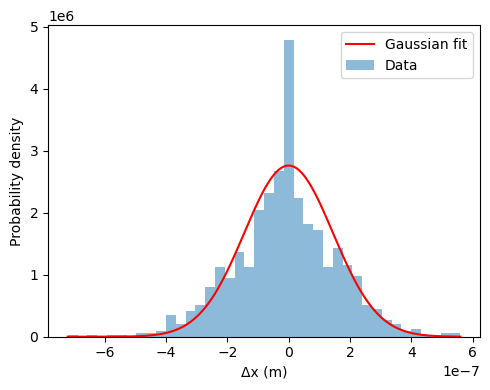

In [136]:


dx = np.diff(df["x"].to_numpy())
dy = np.diff(df["y"].to_numpy())
dt = df["t_fixed"].to_numpy()[1] - df["t_fixed"].to_numpy()[0]


steps = dx


num_bins = 40
hist, bin_edges = np.histogram(steps, bins=num_bins, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def step_pdf(x, D):
    return 1.0 / np.sqrt(4 * np.pi * D * dt) * np.exp(-x**2 / (4 * D * dt))

popt, pcov = curve_fit(step_pdf, bin_centers, hist, p0=[1e-12])
D_fit = popt[0]
D_err = np.sqrt(pcov[0, 0])

print(f"D_fit = ({D_fit*1e12:.3f} ± {D_err*1e12:.3f}) µm²/s")


eta = 0.001
a   = 0.51e-6
T   = 293.15

k_step  = 6 * np.pi * eta * a * D_fit / T
dk_step = 6 * np.pi * eta * a * D_err / T
k_true  = 1.380649e-23

print(f"k_step = ({k_step:.3e} ± {dk_step:.3e}) J/K")
print(f"k_true = {k_true:.3e} J/K")
print(f"Relative error in k ≈ {abs(k_step-k_true)/k_true*100:.1f}%")


x_plot = np.linspace(bin_edges[0], bin_edges[-1], 400)
plt.figure(figsize=(5,4))
plt.bar(bin_centers, hist, width=bin_edges[1]-bin_edges[0], alpha=0.5, label="Data")
plt.plot(x_plot, step_pdf(x_plot, D_fit), "r-", label="Gaussian fit")
plt.xlabel("Δx (m)")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.show()


We improved the step‑distribution analysis by combining both \(x\) and \(y\) frame‑to‑frame displacements, which increases the number of samples and reduces statistical noise. We also chose the histogram bin count based on the data size and fitted only the central reral region $|\Delta r| \le 3\sigma$, where the distribution is most Gaussian, to avoid bias from noisy tails.

D_fit = (0.363 ± 0.066) µm²/s
k_step = (1.190e-23 ± 2.169e-24) J/K
k_true = 1.381e-23 J/K
Relative error in k ≈ 13.8%


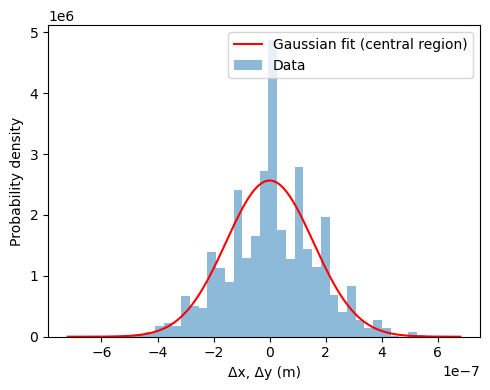

In [137]:
##CLEANED


x = df["x"].to_numpy()
y = df["y"].to_numpy()
t = df["t_fixed"].to_numpy()

dx = np.diff(x)
dy = np.diff(y)
dt = t[1] - t[0]


steps = np.concatenate([dx, dy])

num_bins = int(np.sqrt(len(steps)))  # rule-of-thumb for bin count
hist, bin_edges = np.histogram(steps, bins=num_bins, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def step_pdf(x, D):
    return 1.0 / np.sqrt(4 * np.pi * D * dt) * np.exp(-x**2 / (4 * D * dt))

# Restrict fit to central region |Δx| <= 3 * sigma_est
sigma_est = np.std(steps)
mask = np.abs(bin_centers) <= 3 * sigma_est

popt, pcov = curve_fit(
    step_pdf,
    bin_centers[mask],
    hist[mask],
    p0=[1e-12]
)
D_fit = popt[0]
D_err = np.sqrt(pcov[0, 0])

print(f"D_fit = ({D_fit*1e12:.3f} ± {D_err*1e12:.3f}) µm²/s")

# 4) Convert D to k_B via Stokes–Einstein
eta = 0.001      # Pa·s
a   = 0.51e-6    # m
T   = 293.15     # K

k_step  = 6 * np.pi * eta * a * D_fit / T
dk_step = 6 * np.pi * eta * a * D_err / T
k_true  = 1.380649e-23  # J/K

rel_err_k_pct = 100 * abs(k_step - k_true) / k_true

print(f"k_step = ({k_step:.3e} ± {dk_step:.3e}) J/K")
print(f"k_true = {k_true:.3e} J/K")
print(f"Relative error in k ≈ {rel_err_k_pct:.1f}%")

# 5) Plot histogram and fit
x_plot = np.linspace(bin_edges[0], bin_edges[-1], 400)

plt.figure(figsize=(5, 4))
plt.bar(bin_centers, hist,
        width=bin_edges[1] - bin_edges[0],
        alpha=0.5, label="Data")
plt.plot(x_plot, step_pdf(x_plot, D_fit),
         "r-", label="Gaussian fit (central region)")
plt.xlabel("Δx, Δy (m)")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.show()
